In [1]:
import pandas as pd
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

try:
    import umap.umap_ as umap
except ImportError as e:
    raise ImportError("UMAP is not installed. Run `pip install umap-learn` and try again.") from e

# =========================
# Config
# =========================
CACHE_FILES = {
    "PlantVillage": Path("/root/DINO3/cache/dinov3_plantvillage_color_embeddings.pt"),
    "PlantDoc": Path("/root/DINO3/cache/dinov3_plantdoc_embeddings.pt"),
    "PlantWild": Path("/root/DINO3/cache/dinov3_plantwild_embeddings.pt"),
}

# 비교할 도메인 선택
ACTIVE_DOMAINS = ["PlantVillage", "PlantDoc", "PlantWild"]

# crop-wise cosine은 full 임베딩 기반, UMAP/t-SNE는 샘플링 기반
RANDOM_STATE = 42
MAX_SAMPLES_PER_DOMAIN = 4000

UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.1
UMAP_METRIC = "cosine"

TARGET_CROPS = [
    "apple", "bell pepper", "blueberry", "cherry", "corn", "grape", "peach",
    "potato", "raspberry", "soybean", "squash", "strawberry", "tomato",
]
TARGET_CROP_SET = set(TARGET_CROPS)

DOMAIN_COLORS = {
    "PlantVillage": "#1f77b4",
    "PlantDoc": "#ff7f0e",
    "PlantWild": "#2ca02c",
}

BINARY_COLORS = {
    "healthy": "#2ca02c",
    "disease": "#d62728",
}

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

PLANTVILLAGE_ROOT = Path("/root/DINO3/dataset/PlantVillage")
PLANTDOC_ROOT = Path("/root/DINO3/dataset/PlantDoc-Object-Detection-Dataset")
PLANTWILD_ROOT = Path("/root/DINO3/dataset/plantwild/images")


def extract_binary_label(domain, class_label):
    """Return only two dataset classes: healthy or disease.

    Rule:
    - Any label containing disease-related keywords -> disease
    - Any label containing healthy/leaf-like healthy keywords -> healthy
    - Otherwise default to disease, because most non-healthy plant-disease labels are disease classes.
    """
    s = str(class_label).lower()
    s_norm = s.replace("_", " ").replace("-", " ").replace("/", " ")
    s_norm = " ".join(s_norm.split())

    # Strong healthy indicators
    healthy_keywords = [
        "healthy",
        "health",
        "normal",
        "fresh leaf",
        "green leaf",
        "leaf",
        "leaves",
    ]

    # Disease indicators. Checked before generic PlantDoc/PlantWild leaf fallback.
    disease_keywords = [
        "scab", "black rot", "cedar apple rust", "rust", "blight", "spot",
        "septoria", "mold", "mildew", "virus", "mosaic", "curl", "canker",
        "greening", "anthracnose", "smut", "rot", "mite", "bacterial",
        "disease", "speck", "powdery", "target", "leaf scorch", "leaf mold",
        "yellow", "brown", "gray", "grey", "necrosis", "wilt",
    ]

    for k in disease_keywords:
        if k in s_norm:
            return "disease"

    # PlantVillage has explicit healthy class names.
    if domain == "PlantVillage":
        return "healthy" if "healthy" in s_norm else "disease"

    # PlantDoc / PlantWild sometimes use plain crop leaf names for healthy samples.
    for k in healthy_keywords:
        if k in s_norm:
            return "healthy"

    return "disease"


def load_cached_embeddings(cache_path: Path) -> np.ndarray:
    if not cache_path.exists():
        raise FileNotFoundError(f"Cache not found: {cache_path}")

    try:
        payload = torch.load(cache_path, map_location="cpu", weights_only=False)
    except TypeError:
        payload = torch.load(cache_path, map_location="cpu")

    if not isinstance(payload, dict) or "embeddings" not in payload:
        raise ValueError(f"Invalid cache format: {cache_path}")

    emb = payload["embeddings"]
    if not torch.is_tensor(emb):
        raise ValueError(f"`embeddings` is not a torch tensor: {cache_path}")

    return emb.detach().cpu().numpy().astype(np.float32)


def sample_embeddings_with_indices(emb: np.ndarray, max_samples: int | None, rng: np.random.Generator):
    n = emb.shape[0]
    if (max_samples is None) or (n <= max_samples):
        idx = np.arange(n, dtype=np.int64)
        return emb, idx

    idx = np.sort(rng.choice(n, size=max_samples, replace=False))
    return emb[idx], idx


def normalize_rows(x: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    norm = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(norm, eps, None)


def _unique_preserve_order(values):
    seen = set()
    out = []
    for v in values:
        if v not in seen:
            seen.add(v)
            out.append(v)
    return out


def load_plantvillage_samples():
    split_files = [
        PLANTVILLAGE_ROOT / "splits" / "color_train.txt",
        PLANTVILLAGE_ROOT / "splits" / "color_test.txt",
    ]

    image_paths = []
    for split_file in split_files:
        if not split_file.exists():
            continue
        for line in split_file.read_text(encoding="utf-8").splitlines():
            rel = line.strip()
            if not rel:
                continue
            p = PLANTVILLAGE_ROOT / rel
            if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                image_paths.append(p)

    if len(image_paths) == 0:
        color_root = PLANTVILLAGE_ROOT / "raw" / "color"
        image_paths = [p for p in color_root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]

    image_paths = sorted(set(image_paths))
    class_labels = [p.parent.name for p in image_paths]
    return image_paths, class_labels


def _collect_plantdoc_split_samples(split_name: str, csv_path: Path):
    split_dir = PLANTDOC_ROOT / split_name
    if not csv_path.exists():
        raise ValueError(f"CSV not found: {csv_path}")

    df = pd.read_csv(csv_path)
    grouped = df.groupby("filename", sort=False)["class"].apply(
        lambda s: _unique_preserve_order([str(v).strip() for v in s if pd.notna(v) and str(v).strip()])
    )

    image_paths = []
    class_labels = []

    for filename, classes in grouped.items():
        p = split_dir / str(filename)
        if not p.exists() or p.suffix.lower() not in IMAGE_EXTS:
            continue
        if len(classes) == 0:
            continue
        label = " | ".join(classes)
        image_paths.append(p)
        class_labels.append(label)

    return image_paths, class_labels


def load_plantdoc_samples():
    tr_paths, tr_labels = _collect_plantdoc_split_samples("TRAIN", PLANTDOC_ROOT / "train_labels.csv")
    te_paths, te_labels = _collect_plantdoc_split_samples("TEST", PLANTDOC_ROOT / "test_labels.csv")
    return tr_paths + te_paths, tr_labels + te_labels


def load_plantwild_samples():
    image_paths = [p for p in PLANTWILD_ROOT.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    image_paths = sorted(image_paths)
    class_labels = [p.parent.name for p in image_paths]
    return image_paths, class_labels


def load_domain_samples(domain: str):
    if domain == "PlantVillage":
        return load_plantvillage_samples()
    if domain == "PlantDoc":
        return load_plantdoc_samples()
    if domain == "PlantWild":
        return load_plantwild_samples()
    raise ValueError(f"Unsupported domain: {domain}")


def extract_crop_name(domain: str, class_label: str) -> str:
    s = str(class_label).strip()

    if domain == "PlantVillage":
        crop_raw = s.split("___")[0].lower().strip()
        crop_raw = crop_raw.replace("_", " ").replace(",", " ")
        crop_raw = crop_raw.replace("(", " ").replace(")", " ")
        crop_raw = " ".join(crop_raw.split())
        alias = {"pepper bell": "bell pepper", "cherry including sour": "cherry", "corn maize": "corn"}
        return alias.get(crop_raw, crop_raw)

    if domain == "PlantDoc":
        t = s.split("|")[0].strip().lower()
        if "bell_pepper" in t or "bell pepper" in t:
            return "bell pepper"
        for crop in TARGET_CROPS:
            if t.startswith(crop):
                return crop
        if t.startswith("soyabean"):
            return "soybean"
        return t.split()[0] if t else "unknown"

    if domain == "PlantWild":
        t = str(class_label).lower().strip().replace("_", " ")
        t = " ".join(t.split())
        if t.startswith("bell pepper"):
            return "bell pepper"
        if t.startswith("grapevine"):
            return "grape"
        return t.split()[0] if t else "unknown"

    return "unknown"


def compute_class_centroids(embeddings: np.ndarray, class_labels: np.ndarray):
    unique_classes = np.array(sorted(set(class_labels.tolist())))
    centroids = []
    for cls in unique_classes:
        centroids.append(embeddings[class_labels == cls].mean(axis=0))
    return unique_classes, np.asarray(centroids, dtype=np.float32)


/root/DINO3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# 1) 캐시 임베딩 로드 + 도메인별 라벨 정렬/샘플 준비
rng = np.random.default_rng(RANDOM_STATE)

domain_data = {}

for domain in ACTIVE_DOMAINS:
    emb_full = load_cached_embeddings(CACHE_FILES[domain])
    image_paths, original_class_labels = load_domain_samples(domain)

    if len(original_class_labels) != emb_full.shape[0]:
        raise ValueError(
            f"[{domain}] label count and embedding count mismatch: "
            f"labels={len(original_class_labels):,}, embeddings={emb_full.shape[0]:,}"
        )

    original_class_labels = np.asarray(original_class_labels, dtype=object)
    crop_labels = np.asarray([extract_crop_name(domain, c) for c in original_class_labels], dtype=object)
    binary_labels = np.asarray([extract_binary_label(domain, c) for c in original_class_labels], dtype=object)

    emb_sampled, sampled_idx = sample_embeddings_with_indices(emb_full, MAX_SAMPLES_PER_DOMAIN, rng)

    domain_data[domain] = {
        "emb_full": emb_full,
        "image_paths_full": np.asarray(image_paths, dtype=object),
        "original_class_labels_full": original_class_labels,
        # class_labels_*는 이제 healthy/disease 이진 클래스임
        "class_labels_full": binary_labels,
        "binary_labels_full": binary_labels,
        "crop_labels_full": crop_labels,

        "emb_sampled": emb_sampled,
        "image_paths_sampled": np.asarray(image_paths, dtype=object)[sampled_idx],
        "original_class_labels_sampled": original_class_labels[sampled_idx],
        "class_labels_sampled": binary_labels[sampled_idx],
        "binary_labels_sampled": binary_labels[sampled_idx],
        "crop_labels_sampled": crop_labels[sampled_idx],
    }

    binary_counts = {k: int(np.sum(binary_labels == k)) for k in ["healthy", "disease"]}
    print(
        f"{domain}: full={emb_full.shape[0]:,}, sampled={emb_sampled.shape[0]:,}, "
        f"original_classes={len(set(original_class_labels.tolist()))}, crops={len(set(crop_labels.tolist()))}, "
        f"binary_counts={binary_counts}"
    )

X = np.concatenate([domain_data[d]["emb_sampled"] for d in ACTIVE_DOMAINS], axis=0)
y_domain = np.concatenate([
    np.array([d] * domain_data[d]["emb_sampled"].shape[0], dtype=object)
    for d in ACTIVE_DOMAINS
])
y_binary = np.concatenate([domain_data[d]["binary_labels_sampled"] for d in ACTIVE_DOMAINS], axis=0)
y_crop = np.concatenate([domain_data[d]["crop_labels_sampled"] for d in ACTIVE_DOMAINS], axis=0)

compare_data = {
    "domain_data": domain_data,
    "X": X,
    "y_domain": y_domain,
    "y_binary": y_binary,
    "y_crop": y_crop,
    "active_domains": list(ACTIVE_DOMAINS),
}

print(f"Combined sampled points for UMAP/t-SNE: {X.shape[0]:,}")


PlantVillage: full=54,305, sampled=4,000, original_classes=38, crops=14, binary_counts={'healthy': 15084, 'disease': 39221}
PlantDoc: full=2,578, sampled=2,578, original_classes=37, crops=13, binary_counts={'healthy': 847, 'disease': 1731}
PlantWild: full=18,542, sampled=4,000, original_classes=89, crops=33, binary_counts={'healthy': 7840, 'disease': 10702}
Combined sampled points for UMAP/t-SNE: 10,578


In [7]:
from sklearn.manifold import TSNE

# =========================
# Target config
# =========================
TARGET_CROP = "apple"       # 예: "tomato", "potato", "apple"
TARGET_BINARY_LABEL = None    # None, "healthy", "disease" 중 하나. None이면 healthy/disease 모두 사용
MAX_SAMPLES_PER_DOMAIN_CROP = 1000


def build_target_domain_shift_data(
    compare_data,
    target_crop,
    target_binary_label=None,
    max_samples_per_domain=1000,
    random_state=42,
):
    rng = np.random.default_rng(random_state)

    X_list = []
    y_domain_list = []
    y_class_list = []
    y_binary_list = []
    y_crop_list = []
    y_original_class_list = []

    selected_info = {}

    for domain in compare_data["active_domains"]:
        d = compare_data["domain_data"][domain]

        emb = d["emb_full"]
        binary_labels = d["binary_labels_full"]
        crop_labels = d["crop_labels_full"]
        original_class_labels = d["original_class_labels_full"]

        mask = crop_labels == target_crop

        if target_binary_label is not None:
            target_binary_label = str(target_binary_label).lower().strip()
            if target_binary_label not in {"healthy", "disease"}:
                raise ValueError('TARGET_BINARY_LABEL must be one of None, "healthy", "disease"')
            mask = mask & (binary_labels == target_binary_label)

        idx = np.where(mask)[0]

        if len(idx) == 0:
            print(f"[WARN] {domain}: no samples for crop={target_crop}, binary_label={target_binary_label}")
            continue

        if len(idx) > max_samples_per_domain:
            idx = np.sort(rng.choice(idx, size=max_samples_per_domain, replace=False))

        X_list.append(emb[idx])
        y_domain_list.append(np.array([domain] * len(idx), dtype=object))
        y_class_list.append(binary_labels[idx])
        y_binary_list.append(binary_labels[idx])
        y_crop_list.append(crop_labels[idx])
        y_original_class_list.append(original_class_labels[idx])

        selected_info[domain] = {
            "n": len(idx),
            "binary_counts": {k: int(np.sum(binary_labels[idx] == k)) for k in ["healthy", "disease"]},
            "original_classes": sorted(set(original_class_labels[idx].tolist())),
        }

        print(f"{domain}: selected={len(idx):,}, binary_counts={selected_info[domain]['binary_counts']}")
        print("  original classes:")
        for cls in selected_info[domain]["original_classes"][:20]:
            print(f"  - {cls}")
        if len(selected_info[domain]["original_classes"]) > 20:
            print(f"  ... {len(selected_info[domain]['original_classes']) - 20} more classes")

    if len(X_list) == 0:
        raise ValueError("No samples selected. Check TARGET_CROP or TARGET_BINARY_LABEL.")

    return {
        "X": np.concatenate(X_list, axis=0),
        "y_domain": np.concatenate(y_domain_list, axis=0),
        "y_class": np.concatenate(y_class_list, axis=0),       # healthy/disease
        "y_binary": np.concatenate(y_binary_list, axis=0),     # healthy/disease
        "y_crop": np.concatenate(y_crop_list, axis=0),
        "y_original_class": np.concatenate(y_original_class_list, axis=0),
        "selected_info": selected_info,
    }


target_data = build_target_domain_shift_data(
    compare_data=compare_data,
    target_crop=TARGET_CROP,
    target_binary_label=TARGET_BINARY_LABEL,
    max_samples_per_domain=MAX_SAMPLES_PER_DOMAIN_CROP,
    random_state=RANDOM_STATE,
)

print("Target X:", target_data["X"].shape)


PlantVillage: selected=1,000, binary_counts={'healthy': 517, 'disease': 483}
  original classes:
  - Apple___Apple_scab
  - Apple___Black_rot
  - Apple___Cedar_apple_rust
  - Apple___healthy
PlantDoc: selected=273, binary_counts={'healthy': 91, 'disease': 182}
  original classes:
  - Apple Scab Leaf
  - Apple leaf
  - Apple rust leaf
PlantWild: selected=1,000, binary_counts={'healthy': 307, 'disease': 693}
  original classes:
  - apple black rot
  - apple leaf
  - apple mosaic virus
  - apple rust
  - apple scab
Target X: (2273, 768)


/root/DINO3/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


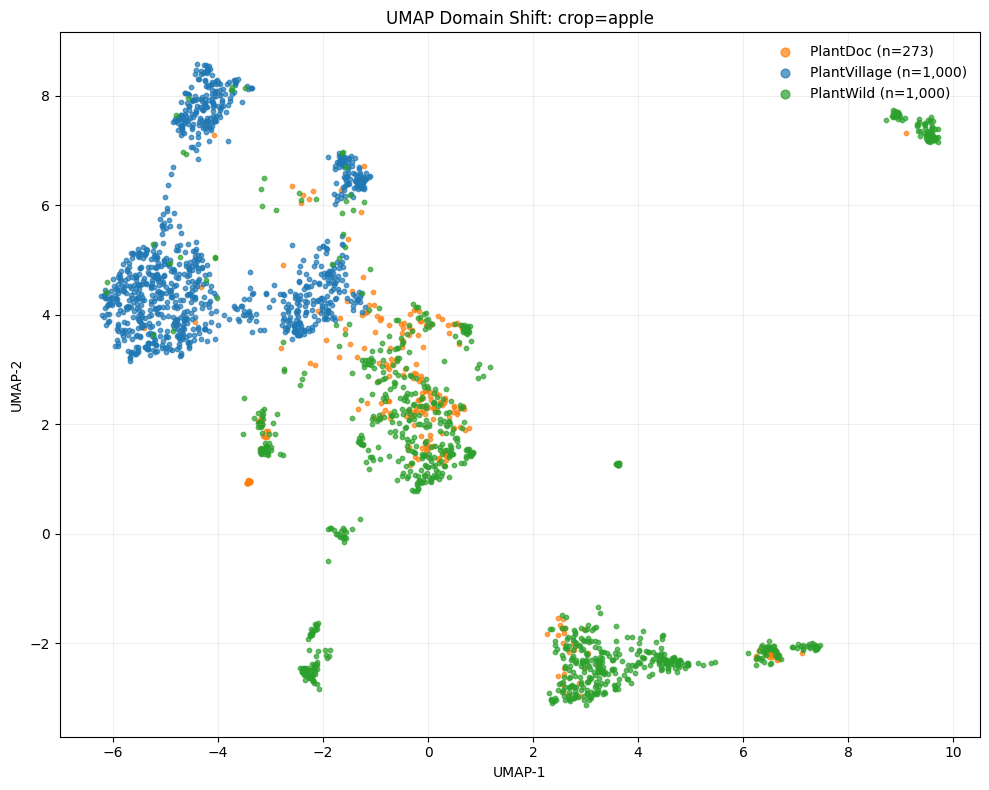

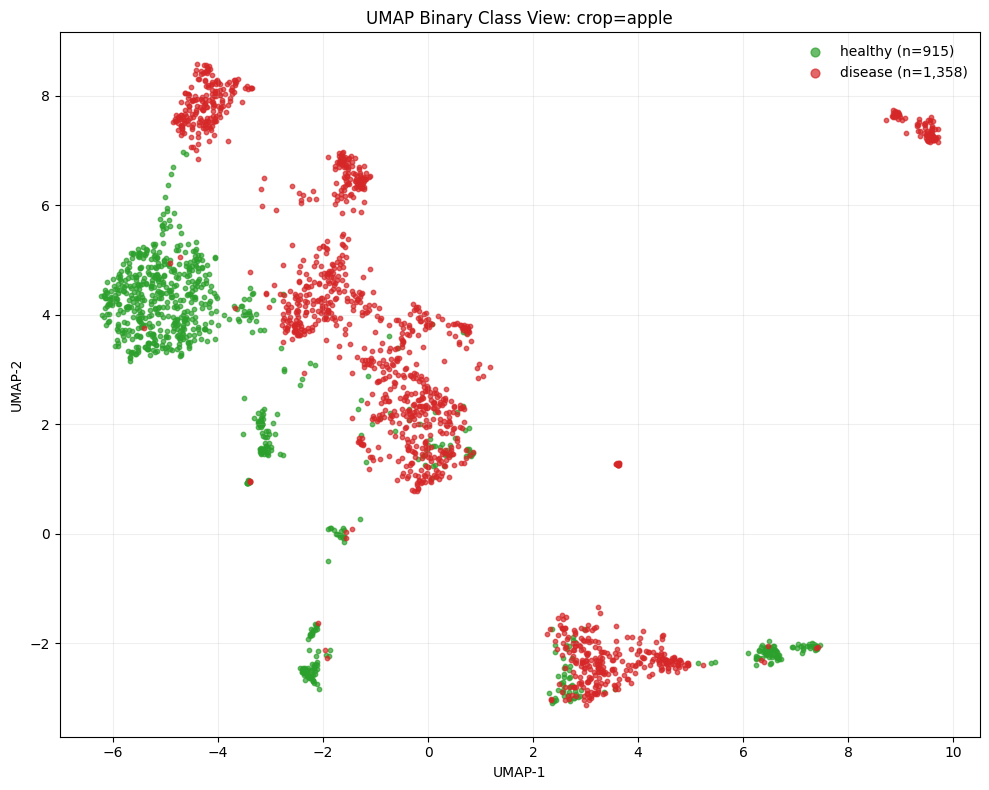

In [8]:
X_t = target_data["X"]
y_domain_t = target_data["y_domain"]
y_binary_t = target_data["y_binary"]

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=min(UMAP_N_NEIGHBORS, X_t.shape[0] - 1),
    min_dist=UMAP_MIN_DIST,
    metric=UMAP_METRIC,
    random_state=RANDOM_STATE,
    low_memory=True,
)

coords_umap = reducer.fit_transform(X_t)

# 도메인별 UMAP
plt.figure(figsize=(10, 8))
for domain in sorted(set(y_domain_t.tolist())):
    mask = y_domain_t == domain
    plt.scatter(
        coords_umap[mask, 0], coords_umap[mask, 1],
        s=10, alpha=0.7, c=DOMAIN_COLORS.get(domain, None),
        label=f"{domain} (n={mask.sum():,})",
    )

title = f"UMAP Domain Shift: crop={TARGET_CROP}"
if TARGET_BINARY_LABEL is not None:
    title += f", binary={TARGET_BINARY_LABEL}"
plt.title(title)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(markerscale=2, frameon=False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# healthy/disease별 UMAP
plt.figure(figsize=(10, 8))
for label in ["healthy", "disease"]:
    mask = y_binary_t == label
    if not np.any(mask):
        continue
    plt.scatter(
        coords_umap[mask, 0], coords_umap[mask, 1],
        s=10, alpha=0.7, c=BINARY_COLORS.get(label, None),
        label=f"{label} (n={mask.sum():,})",
    )

plt.title(f"UMAP Binary Class View: crop={TARGET_CROP}")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.legend(markerscale=2, frameon=False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


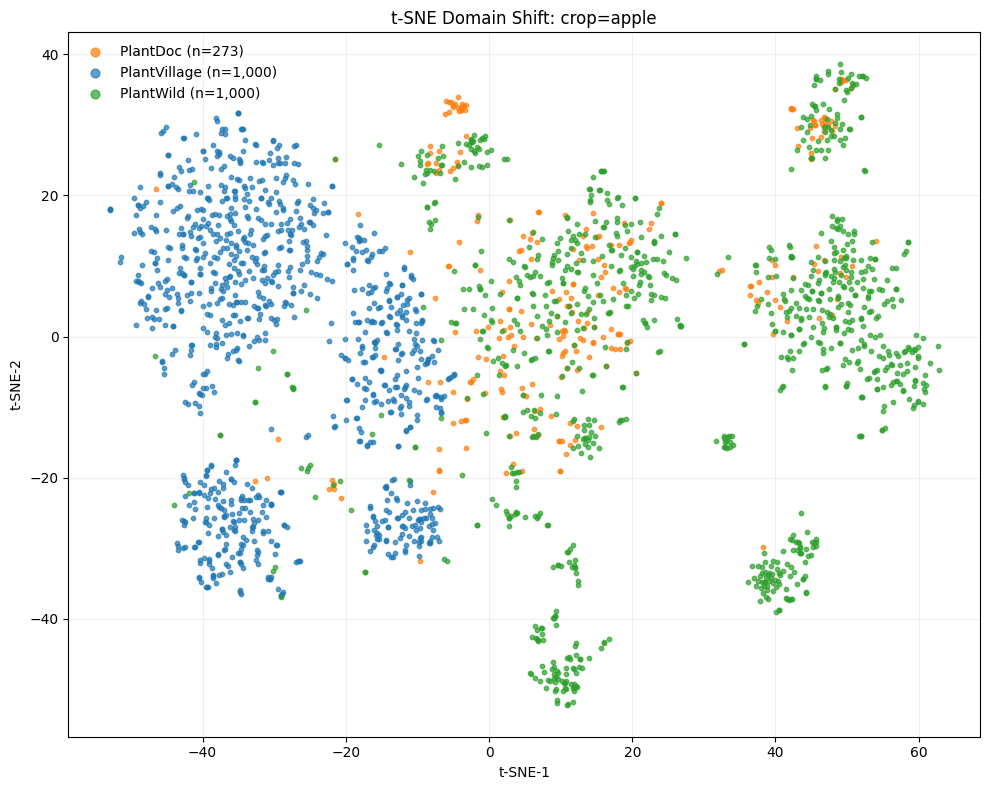

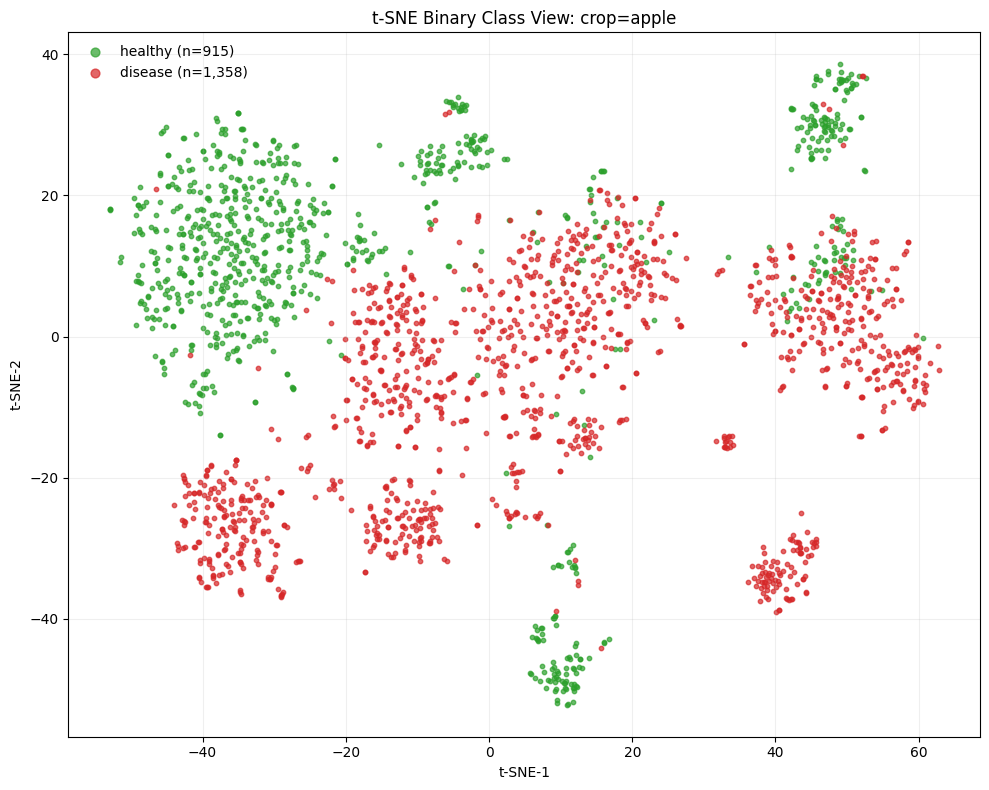

In [9]:
X_t = target_data["X"]
y_domain_t = target_data["y_domain"]
y_binary_t = target_data["y_binary"]

perplexity = min(30, max(5, (X_t.shape[0] - 1) // 3))

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    metric="cosine",
    init="pca",
    learning_rate="auto",
    random_state=RANDOM_STATE,
)

coords_tsne = tsne.fit_transform(X_t)

# 도메인별 t-SNE
plt.figure(figsize=(10, 8))
for domain in sorted(set(y_domain_t.tolist())):
    mask = y_domain_t == domain
    plt.scatter(
        coords_tsne[mask, 0], coords_tsne[mask, 1],
        s=10, alpha=0.7, c=DOMAIN_COLORS.get(domain, None),
        label=f"{domain} (n={mask.sum():,})",
    )

title = f"t-SNE Domain Shift: crop={TARGET_CROP}"
if TARGET_BINARY_LABEL is not None:
    title += f", binary={TARGET_BINARY_LABEL}"
plt.title(title)
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.legend(markerscale=2, frameon=False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

# healthy/disease별 t-SNE
plt.figure(figsize=(10, 8))
for label in ["healthy", "disease"]:
    mask = y_binary_t == label
    if not np.any(mask):
        continue
    plt.scatter(
        coords_tsne[mask, 0], coords_tsne[mask, 1],
        s=10, alpha=0.7, c=BINARY_COLORS.get(label, None),
        label=f"{label} (n={mask.sum():,})",
    )

plt.title(f"t-SNE Binary Class View: crop={TARGET_CROP}")
plt.xlabel("t-SNE-1")
plt.ylabel("t-SNE-2")
plt.legend(markerscale=2, frameon=False)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [6]:
# 3) Cross-domain Crop-wise Binary Class Cosine Similarity
# class_labels_full은 healthy/disease 이진 클래스임
if "compare_data" not in globals():
    raise RuntimeError("`compare_data` not found. Run embedding-load cell first.")

active_domains = compare_data["active_domains"]
domain_data = compare_data["domain_data"]

print("Plotting cross-domain crop-wise binary-class cosine similarity matrices...")


def get_crop_binary_centroids(domain: str, crop: str):
    emb = domain_data[domain]["emb_full"]
    binary = domain_data[domain]["binary_labels_full"]
    crp = domain_data[domain]["crop_labels_full"]

    mask = (crp == crop)
    if not np.any(mask):
        return None, None

    return compute_class_centroids(emb[mask], binary[mask])


for crop in TARGET_CROPS:
    domains_with_crop = [
        domain for domain in active_domains
        if np.any(domain_data[domain]["crop_labels_full"] == crop)
    ]

    if len(domains_with_crop) < 2:
        continue

    domain_pairs = [
        (domains_with_crop[i], domains_with_crop[j])
        for i in range(len(domains_with_crop))
        for j in range(i + 1, len(domains_with_crop))
    ]

    fig, axes = plt.subplots(1, len(domain_pairs), figsize=(6 * len(domain_pairs), 4.8))
    if len(domain_pairs) == 1:
        axes = [axes]

    plotted_any = False

    for ax, (left_domain, right_domain) in zip(axes, domain_pairs):
        left_classes, left_centroids = get_crop_binary_centroids(left_domain, crop)
        right_classes, right_centroids = get_crop_binary_centroids(right_domain, crop)

        if left_classes is None or right_classes is None:
            ax.axis("off")
            continue

        left_norm = normalize_rows(left_centroids)
        right_norm = normalize_rows(right_centroids)
        sim = left_norm @ right_norm.T

        im = ax.imshow(sim, vmin=-1, vmax=1, cmap="viridis", aspect="auto")
        x_labels = right_classes.tolist()
        y_labels = left_classes.tolist()
        ax.set_xticks(range(len(x_labels)))
        ax.set_yticks(range(len(y_labels)))
        ax.set_xticklabels(x_labels, rotation=0, fontsize=10)
        ax.set_yticklabels(y_labels, fontsize=10)
        ax.set_xlabel(right_domain)
        ax.set_ylabel(left_domain)
        ax.set_title(f"{left_domain} vs {right_domain} | {crop}
healthy/disease centroids")

        for yi in range(sim.shape[0]):
            for xi in range(sim.shape[1]):
                ax.text(xi, yi, f"{sim[yi, xi]:.2f}", ha="center", va="center", color="white", fontsize=9)

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        plotted_any = True

    if plotted_any:
        fig.suptitle(f"Cross-Domain Crop-wise Binary Class Cosine Similarity: {crop}", y=1.03)
        plt.tight_layout()
        plt.show()

print("Done.")


SyntaxError: unterminated f-string literal (detected at line 66) (826194367.py, line 66)

In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Apple
# =========================

apple_domain = np.array([
    [0.0000, 0.2591, 0.3050],
    [0.2609, 0.0000, 0.0807],
    [0.3088, 0.0743, 0.0000]
])

apple_class = np.array([
    [0.0000, 0.1307],
    [0.1329, 0.0000]
])

# =========================
# Tomato
# =========================

tomato_domain = np.array([
    [0.0000, 0.2436, 0.2774],
    [0.2418, 0.0000, 0.0209],
    [0.2722, 0.0209, 0.0000]
])

tomato_class = np.array([
    [0.0000, 0.0881],
    [0.0900, 0.0000]
])

domain_labels = ["PlantVillage", "PlantDoc", "PlantWild"]
class_labels = ["Healthy", "Diseased"]

# =========================
# Plot
# =========================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Apple Domain
sns.heatmap(
    apple_domain,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    xticklabels=domain_labels,
    yticklabels=domain_labels,
    ax=axes[0,0]
)
axes[0,0].set_title("Apple Domain Distance")

# Apple Class
sns.heatmap(
    apple_class,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    xticklabels=class_labels,
    yticklabels=class_labels,
    ax=axes[0,1]
)
axes[0,1].set_title("Apple Class Distance")

# Tomato Domain
sns.heatmap(
    tomato_domain,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    xticklabels=domain_labels,
    yticklabels=domain_labels,
    ax=axes[1,0]
)
axes[1,0].set_title("Tomato Domain Distance")

# Tomato Class
sns.heatmap(
    tomato_class,
    annot=True,
    fmt=".4f",
    cmap="viridis",
    xticklabels=class_labels,
    yticklabels=class_labels,
    ax=axes[1,1]
)
axes[1,1].set_title("Tomato Class Distance")

plt.tight_layout()
plt.show()